In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats

In [2]:
os.getcwd()

'C:\\Users\\jmeek\\Desktop'

In [3]:
df = pd.read_csv("AdRevenue.csv")

In [4]:
df.head()

,Magazine,"PARENT COMPANY, SUBSIDIARY",AdRevenue,Circulation
0,People,"Time Warner, (Time Inc.)",233.259,3.751
1,Better Homes and Gardens,Meredith Corp.,396.865,7.639
2,Time,"Time Warner, (Time Inc.)",286.108,4.067
3,Parade (1),"Advance Publications, (Parade Publications)",876.907,32.700
4,Sports Illustrated,"Time Warner, (Time Inc.)",304.185,3.205


In [5]:
y = df["AdRevenue"]
x = df["Circulation"]

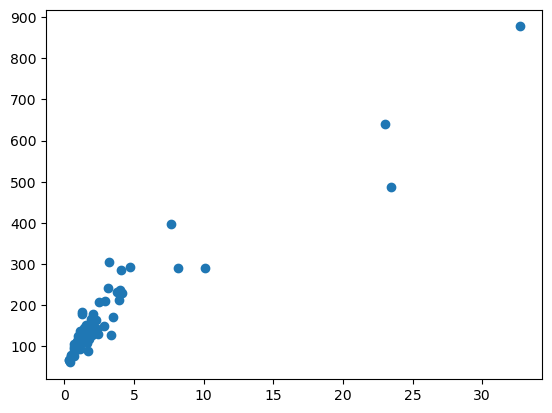

In [6]:
plt.scatter(x,y)
#scatterplot of predictor vs response variables appears to not violate any OLS assumptions, thus no transformations are necessary and SLR can proceed

In [7]:
X = sm.add_constant(x)

In [8]:
SLR = sm.OLS(y, X).fit()

In [9]:
SLR.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              AdRevenue   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     576.5
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           6.29e-35
Time:                        13:45:55   Log-Likelihood:                -360.32
No. Observations:                  70   AIC:                             724.6
Df Residuals:                      68   BIC:                             729.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          99.8095      5.855     17.048      0.000      88.127     111.492
Circulation    22.8534      0.952     24.011      0.000      20.954      24.753
==============================================================================
Omnibus:                       12.704   Durbin-Watson:                   1.159
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               26.354
Skew:                           0.508   Prob(JB):                     1.89e-06
Kurtosis:                       5.829   Cond. No.                         7.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
yhat1 = 99.810 + (0.5 * 22.8534)
yhat2 = 99.810 + (20 * 22.8534)
yhat1, yhat2


(111.2367, 556.8779999999999)

In [11]:
sy = np.sqrt(SLR.mse_resid)
xbar = x.mean()
sxx = ((x - xbar)**2).sum()

In [12]:
PIyhat1 = yhat1 - 2.0 * sy * np.sqrt(1 + 1/68 + ((0.5-xbar)/sxx)), yhat1 + 2.0 * sy * np.sqrt(1 + 1/68 + ((0.5-xbar)/sxx))
PIyhat2 = yhat2 - 2.0 * sy * np.sqrt(1 + 1/68 + ((20-xbar)/sxx)), yhat2 + 2.0 * sy * np.sqrt(1 + 1/68 + ((20-xbar)/sxx))
PIyhat1, PIyhat2

((np.float64(26.229878597820473), np.float64(196.2435214021795)),
 (np.float64(471.45656787992266), np.float64(642.2994321200772)))

In [13]:
#For a single magazine, given the circulation is 0.5 million, on the SLR model we are 95% confident the ad revenue will fall between 26.23 thousand and 196.24 thousand
#For a single magazine, given the circulation is 20 million, on the SLR model we are 95% confident the ad revenue will fall between 471.456 thousand and 642.29 thousand

In [14]:
#The model is overly simplistic, and the intercept makes very little real world sense. The model "works" but is likely very biased and underfits the true relationship

In [15]:
#Advertising and media products tend to have marginal returns that decrease over time, i.e a magazine with 30 million viewers is fighting for the same ad revenue
# as a magazine with 40 million viewers, thus a quadratic and cubic term will be introduced to see if they better capture the relationship.

In [16]:
df['CirculationSquared'] = (df["Circulation"])**2
df['CirculationCubed'] = (df["Circulation"])**3

In [17]:
X2 = sm.add_constant(df[['Circulation', 'CirculationSquared']])
X3 = sm.add_constant(df[['Circulation', 'CirculationSquared', 'CirculationCubed']])
SLR2 = sm.OLS(y, X2).fit()
SLR3 = sm.OLS(y, X3).fit()

In [18]:
SLR2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              AdRevenue   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     304.9
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           2.25e-34
Time:                        13:45:59   Log-Likelihood:                -358.09
No. Observations:                  70   AIC:                             722.2
Df Residuals:                      67   BIC:                             728.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 88.1390      7.971     11.058      0.000      72.229     104.049
Circulation           29.5006      3.299      8.942      0.000      22.915      36.086
CirculationSquared    -0.2394      0.114     -2.100      0.040      -0.467      -0.012
==============================================================================
Omnibus:                       11.423   Durbin-Watson:                   1.167
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               35.277
Skew:                           0.011   Prob(JB):                     2.19e-08
Kurtosis:                       6.478   Cond. No.                         269.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
SLR3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              AdRevenue   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     308.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           9.74e-39
Time:                        13:45:59   Log-Likelihood:                -344.24
No. Observations:                  70   AIC:                             696.5
Df Residuals:                      66   BIC:                             705.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 59.1704      8.345      7.090      0.000      42.509      75.832
Circulation           51.2358      4.711     10.875      0.000      41.830      60.642
CirculationSquared    -2.5054      0.411     -6.090      0.000      -3.327      -1.684
CirculationCubed       0.0522      0.009      5.658      0.000       0.034       0.071
==============================================================================
Omnibus:                        8.701   Durbin-Watson:                   1.745
Prob(Omnibus):                  0.013   Jarque-Bera (JB):               10.974
Skew:                           0.508   Prob(JB):                      0.00414
Kurtosis:                       4.653   Cond. No.                     1.08e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.08e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
#Cube model is valid as can be seen from the strong p value for the cubed term

In [21]:
halfamil = [1, 0.5, .25, .125]
twentymil = [1, 20, 400, 8000]
predhalfamil = SLR3.get_prediction([halfamil])
predtwentymil = SLR3.get_prediction([twentymil])

In [22]:
predhalfamil.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,84.16846,6.515714,71.159417,97.177503,14.923142,153.413778


In [23]:
predtwentymil.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,499.53342,22.359125,454.891986,544.174854,418.179032,580.887808


In [24]:
#For a single magazine, given the circulation is 0.5 million, on the new polynomial model we are 95% confident the ad revenue will fall between 14.923 thousand and 153.413 thousand
#For a single magazine, given the circulation is 20 million, on the new polynomial model we are 95% confident the ad revenue will fall between 418.179 thousand and 580.88 thousand

In [25]:
#Although this model better captures the circulation cubed, the predictions are still only based off of one factor, the circulation, rather than any other inputs

In [26]:
#The model in part A is overly simplistic, but does do a succesful job capturing the strong linear relationship between circulation and ad revenue. The model has a high R^2 of .89. 
#The model in part B better captures the effect of the circulation but still only uses one factor. The R^2 and adjusted R^2 is higher than the model in part A, .933 and .930, respectively.

In [52]:
#The prediction intervals for the polynomial model are narrower than those for the SLR model, thus since the alpha levels are equal,
#one would choose the narrower model so as to minimze uncertainty and improve the accuarcy of the model

In [29]:
pip install pydataset

     ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
      --------------------------------------- 0.3/15.9 MB ? eta -:--:--
     --------- ------------------------------ 3.9/15.9 MB 14.6 MB/s eta 0:00:01
     --------------------- ------------------ 8.4/15.9 MB 17.2 MB/s eta 0:00:01
     ---------------------------- ---------- 11.8/15.9 MB 17.2 MB/s eta 0:00:01
     ------------------------------------- - 15.5/15.9 MB 16.9 MB/s eta 0:00:01
     ---------------------------------------- 15.9/15.9 MB 16.1 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939227 sha256=354c92a93f37d39ebabb4c40be6c3a1e62

In [28]:
from pydataset import data
df = data('faithful')

In [29]:
df.head()

,eruptions,waiting
1,3.600,79
2,1.800,54
3,3.333,74
4,2.283,62
5,4.533,85


In [30]:
df.describe()

,eruptions,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


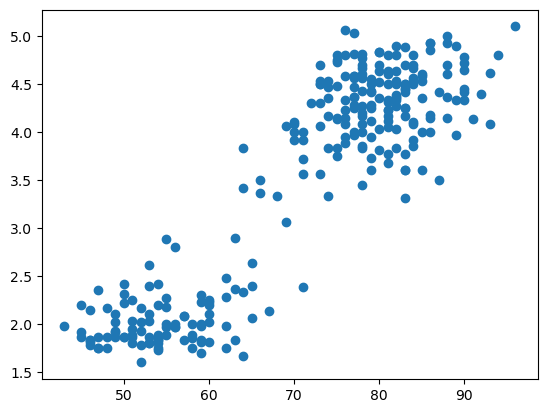

In [31]:
b = df['eruptions']
a = df['waiting']
plt.scatter(a,b)

In [32]:
A = sm.add_constant(a)

In [33]:
FAITHFULSLR = sm.OLS(b,A).fit()

In [34]:
FAITHFULSLR.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              eruptions   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     1162.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          8.13e-100
Time:                        13:46:11   Log-Likelihood:                -194.51
No. Observations:                 272   AIC:                             393.0
Df Residuals:                     270   BIC:                             400.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8740      0.160    -11.702      0.000      -2.189      -1.559
waiting        0.0756      0.002     34.089      0.000       0.071       0.080
==============================================================================
Omnibus:                        4.133   Durbin-Watson:                   2.561
Prob(Omnibus):                  0.127   Jarque-Bera (JB):                3.173
Skew:                          -0.138   Prob(JB):                        0.205
Kurtosis:                       2.548   Cond. No.                         384.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

C:\Users\jmeek\AppData\Local\Temp\ipykernel_7092\909214371.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predline = FAITHFULSLR.params[0] + FAITHFULSLR.params[1] * a


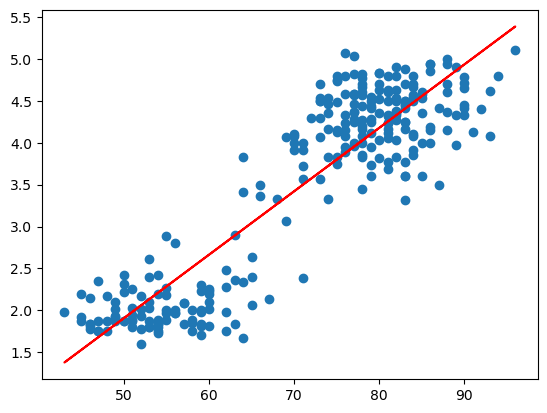

In [35]:
#SLR CHART
predline = FAITHFULSLR.params[0] + FAITHFULSLR.params[1] * a
plt.scatter(a,b)
plt.plot(a, predline, color="red")

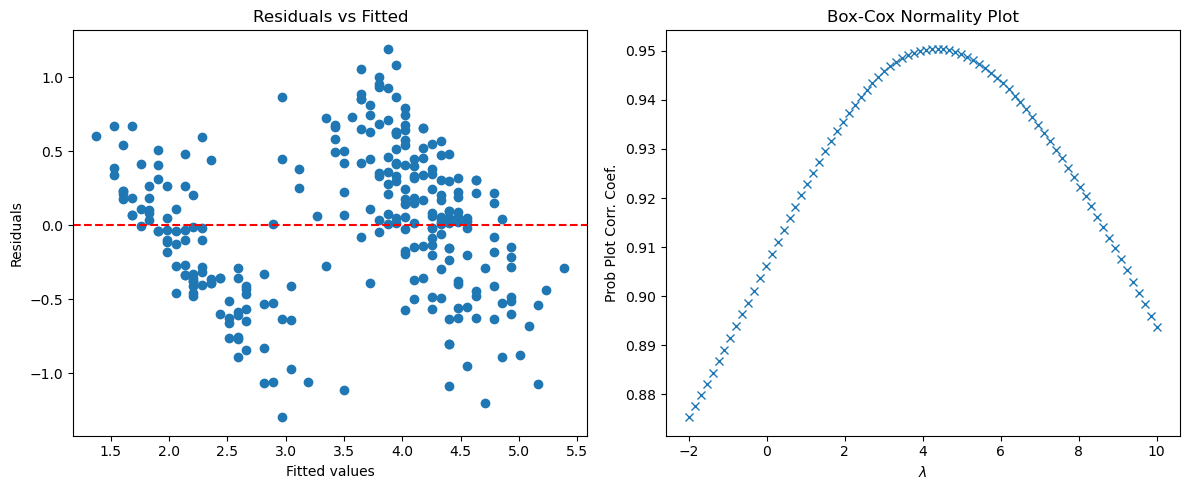

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#Residuals vs Fitted
ax[0].scatter(FAITHFULSLR.fittedvalues, FAITHFULSLR.resid)
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title('Residuals vs Fitted')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')

#Box-Cox Plot
stats.boxcox_normplot(b, -2, 10, plot=ax[1])
ax[1].set_title('Box-Cox Normality Plot')

plt.tight_layout()
plt.show()

In [37]:
#Model has two clusters and a clear non-linear relationship as evidenced by the residual pattern and the boxcox plot.
#Lambda of 4 seems best, transformation below:
#Applying the lambda 4 transformation is best as it best forces the non-linear relationship into a linear form and helps satisfy the normalcy conditions OLS is dependent on
lam = 4
z = df['eruptions']**(lam-1)/lam

C:\Users\jmeek\AppData\Local\Temp\ipykernel_7092\4081133915.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  newpred = transformedfaithful.params[0] + transformedfaithful.params[1] * a


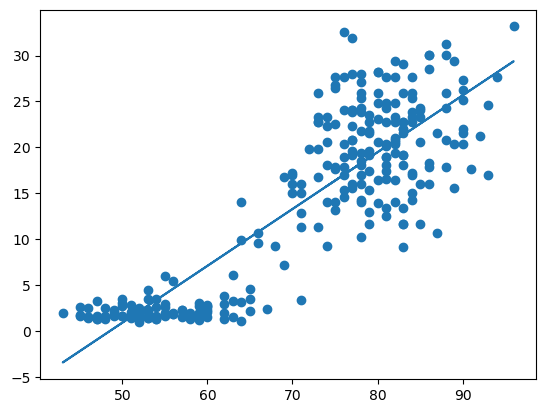

In [38]:
#NEW SLR PLOT
transformedfaithful = sm.OLS(z, A).fit()
newpred = transformedfaithful.params[0] + transformedfaithful.params[1] * a
plt.scatter(a,z)
plt.plot(a, newpred)

In [39]:
#Still not a great model, transformation needs to be done on the predictor variable, not the response.

C:\Users\jmeek\AppData\Local\Temp\ipykernel_7092\142695570.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  newpred = transformedfaithful.params[0] + transformedfaithful.params[1] * a


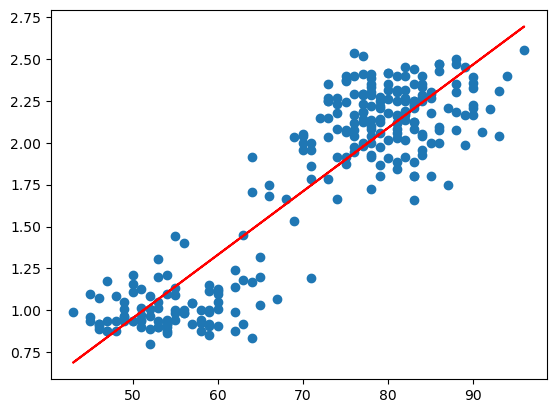

In [41]:
z = df['eruptions']**1/2
transformedfaithful = sm.OLS(z, A).fit()
newpred = transformedfaithful.params[0] + transformedfaithful.params[1] * a
plt.scatter(a,z)
plt.plot(a, newpred, color="red")

In [49]:
newOBSV = [1, 55] 
prediction_obj = transformedfaithful.get_prediction(newOBSV)
ci_frame = prediction_obj.summary_frame(alpha=0.05)
lowerSqrt = ci_frame['mean_ci_lower'][0]
upperSqrt = ci_frame['mean_ci_upper'][0]
lowerMinutes = lowerSqrt**2
upperMinutes = upperSqrt**2
lowerMinutesRounded = lowerMinutes.round(3)
upperMinutesRounded = upperMinutes.round(3)

In [51]:
#Interpretation, technically a median due to backtransformation
f"We are 95% confident that the average length of an eruption given it has been 55 minutes since the last eruption is between {lowerMinutesRounded} minutes and {upperMinutesRounded} minutes"

'We are 95% confident that the average length of an eruption given it has been 55 minutes since the last eruption is between 1.204 minutes and 1.412 minutes'